# 10-Advanced Context Topologies

In Lesson 09, we mastered Query Transformation (HyDE), solving the problem of user-side vocabulary mismatch. We are now retrieving highly relevant documents.

However, we are still bound by a fundamental contradiction in Information Retrieval physics known as the **Chunk Size Paradox**:

1. **Retrieval Precision Demands Small Chunks**: If a chunk is only 1-2 sentences ($100$ tokens), its dense vector embedding is highly concentrated. It represents a single, laser-focused semantic concept. It is easily retrieved.
2. **Generative Comprehension Demands Large Chunks**: If we pass a 1-sentence chunk to an LLM, the model lacks the surrounding context. It might know *what* happened, but it doesn't know *why* or *when*, severely crippling its ability to synthesize a comprehensive answer.

If we increase the chunk size to $1000$ tokens to give the LLM more context, the dense vector becomes diluted with multiple competing concepts, and retrieval recall collapses (The "Lost in the Middle" problem).

To break this paradox, we must completely decouple the retrieval space from the generation space using **Advanced Context Topologies**, specifically **Parent-Child Retrieval** and **Auto-Merging Trees**.

Let's set up our environment to engineer hierarchical context routing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Hierarchical Context Environment Ready.")

✅ Systems Architecture & Hierarchical Context Environment Ready.


# 1. The Physics of Small-to-Big (Parent-Child) Routing

To solve the Chunk Size Paradox, we split our database into two distinct physical stores:

1. **The Vector Store (Child Chunks)**: We shatter the document into tiny, highly dense semantic chunks (e.g., $100$ tokens). We embed these and store them in FAISS/Pinecone.
2. **The Document Store (Parent Chunks)**: We store larger, overarching chunks (e.g., $1000$ tokens, like a full paragraph or page). This is a standard key-value store (e.g., Redis or MongoDB).

Every Child Chunk contains a hidden metadata pointer: `parent_id`.

When the user queries the system, we search the Vector Store. The dense math perfectly isolates the tiny Child Chunk because its vector is mathematically pure. But instead of returning the Child Chunk to the LLM, we intercept the retrieval, read the `parent_id`, execute an $\mathcal{O}(1)$ lookup in the Document Store, and inject the massive Parent Chunk into the LLM's prompt.

We search small, but we read big.

# 2. The Mathematics of Auto-Merging Trees

If a user asks a broad, multi-faceted question, the Vector Database might retrieve multiple Child Chunks that belong to the exact same Parent.

If we blindly inject the Parent Chunk for every retrieved Child Chunk, we will inject the exact same massive paragraph 5 times, instantly blowing up the LLM's Context Window and destroying generation cost limits.

We must implement an **Auto-Merging Retrieval Tree**.
Let $P$ be a Parent Chunk composed of $n$ disjoint Child Chunks $C = \{c_1, c_2, \dots, c_n\}$.
Let $R$ be the set of top-$K$ retrieved child chunks based on the user's query vector.

We define a structural activation threshold $\tau \in [0, 1]$. If the ratio of retrieved children belonging to $P$ exceeds $\tau$, we mathematically collapse the children and replace them with the singular Parent node.

$$\text{If } \frac{|C \cap R|}{n} \geq \tau \implies \text{Collapse } (c_i \in R) \text{ and Inject } P$$

If the threshold is *not* met, we simply return the individual disjoint child chunks, preserving token economy.

# 3. Architecting the Hierarchical Context Router

Let's build a deterministic simulation of a Parent-Child Document Store with an Auto-Merging threshold engine.

In [2]:
# --- 🌳 The Auto-Merging Hierarchical Router ---

class HierarchicalRetriever:
    def __init__(self, merge_threshold: float = 0.50):
        self.merge_threshold = merge_threshold
        
        # 1. The Document Store (Key-Value)
        # Contains the massive, context-rich parent nodes
        self.doc_store = {
            "parent_A": "The X900 Server requires strict maintenance. Step 1: Disconnect power. Step 2: Flush RAM cache. Step 3: Replace core manifold. Failure to disconnect power causes severe short circuits.",
            "parent_B": "HR Policy 401: Remote work is permitted on Fridays. Employees must log hours in the portal. Expense stipends max out at $500 per month."
        }
        
        # 2. The Vector Database Mapping (Simulation)
        # Contains tiny, semantically pure child chunks mapping back to parents
        self.child_metadata = {
            "child_A1": {"parent_id": "parent_A", "text": "Step 1: Disconnect power.", "sibling_count": 4},
            "child_A2": {"parent_id": "parent_A", "text": "Step 2: Flush RAM cache.", "sibling_count": 4},
            "child_A3": {"parent_id": "parent_A", "text": "Step 3: Replace core manifold.", "sibling_count": 4},
            "child_A4": {"parent_id": "parent_A", "text": "Failure to disconnect power causes severe short circuits.", "sibling_count": 4},
            
            "child_B1": {"parent_id": "parent_B", "text": "Remote work is permitted on Fridays.", "sibling_count": 3},
            "child_B2": {"parent_id": "parent_B", "text": "Employees must log hours in the portal.", "sibling_count": 3},
            "child_B3": {"parent_id": "parent_B", "text": "Expense stipends max out at $500 per month.", "sibling_count": 3}
        }

    def process_retrieval(self, retrieved_child_ids: list[str]) -> list[str]:
        print(f"📥 Initial Dense Retrieval (Children): {retrieved_child_ids}")
        
        parent_hit_counts = {}
        
        # Tally hits per parent
        for child_id in retrieved_child_ids:
            parent_id = self.child_metadata[child_id]["parent_id"]
            parent_hit_counts[parent_id] = parent_hit_counts.get(parent_id, 0) + 1
            
        final_context_blocks = []
        processed_parents = set()
        
        # Execute Auto-Merging Calculus
        for child_id in retrieved_child_ids:
            parent_id = self.child_metadata[child_id]["parent_id"]
            
            # Skip if we already collapsed this tree
            if parent_id in processed_parents:
                continue
                
            total_siblings = self.child_metadata[child_id]["sibling_count"]
            hits = parent_hit_counts[parent_id]
            ratio = hits / total_siblings
            
            if ratio >= self.merge_threshold:
                print(f"⚡ COLLAPSE TRIGGERED: Parent '{parent_id}' hit ratio {ratio*100:.1f}% >= threshold {self.merge_threshold*100:.1f}%")
                final_context_blocks.append(f"[MERGED PARENT] {self.doc_store[parent_id]}")
                processed_parents.add(parent_id) # Prevent duplicate injection
            else:
                # If threshold not met, just return the isolated child
                final_context_blocks.append(f"[ISOLATED CHILD] {self.child_metadata[child_id]['text']}")
                
        return final_context_blocks

# 1. Initialize Engine
retriever = HierarchicalRetriever(merge_threshold=0.50) # 50% of children required to trigger parent

# 2. Scenario A: Highly Specific Query
# User asks: "What happens if I don't unplug the server?"
# Dense math finds ONLY child_A4. (1 out of 4 siblings = 25%)
print("\n--- 🔍 Scenario A: Laser-Focused Query ---")
context_a = retriever.process_retrieval(["child_A4"])
for ctx in context_a:
    print(f"Context Provided to LLM: '{ctx}'")

# 3. Scenario B: Broad Conceptual Query
# User asks: "What are the full maintenance steps for the X900?"
# Dense math finds child_A1, child_A2, and child_A3. (3 out of 4 siblings = 75%)
print("\n--- 🔍 Scenario B: Broad Thematic Query ---")
context_b = retriever.process_retrieval(["child_A1", "child_A2", "child_A3"])
for ctx in context_b:
    print(f"Context Provided to LLM: '{ctx}'")


--- 🔍 Scenario A: Laser-Focused Query ---
📥 Initial Dense Retrieval (Children): ['child_A4']
Context Provided to LLM: '[ISOLATED CHILD] Failure to disconnect power causes severe short circuits.'

--- 🔍 Scenario B: Broad Thematic Query ---
📥 Initial Dense Retrieval (Children): ['child_A1', 'child_A2', 'child_A3']
⚡ COLLAPSE TRIGGERED: Parent 'parent_A' hit ratio 75.0% >= threshold 50.0%
Context Provided to LLM: '[MERGED PARENT] The X900 Server requires strict maintenance. Step 1: Disconnect power. Step 2: Flush RAM cache. Step 3: Replace core manifold. Failure to disconnect power causes severe short circuits.'


# 4. Visualizing Hierarchical Graph Collapse

To understand the structural physics of the Auto-Merging tree, let's plot the graph topology of a Parent node and its Children, demonstrating how the $\tau$ threshold mathematically rewires the retrieval pathways.

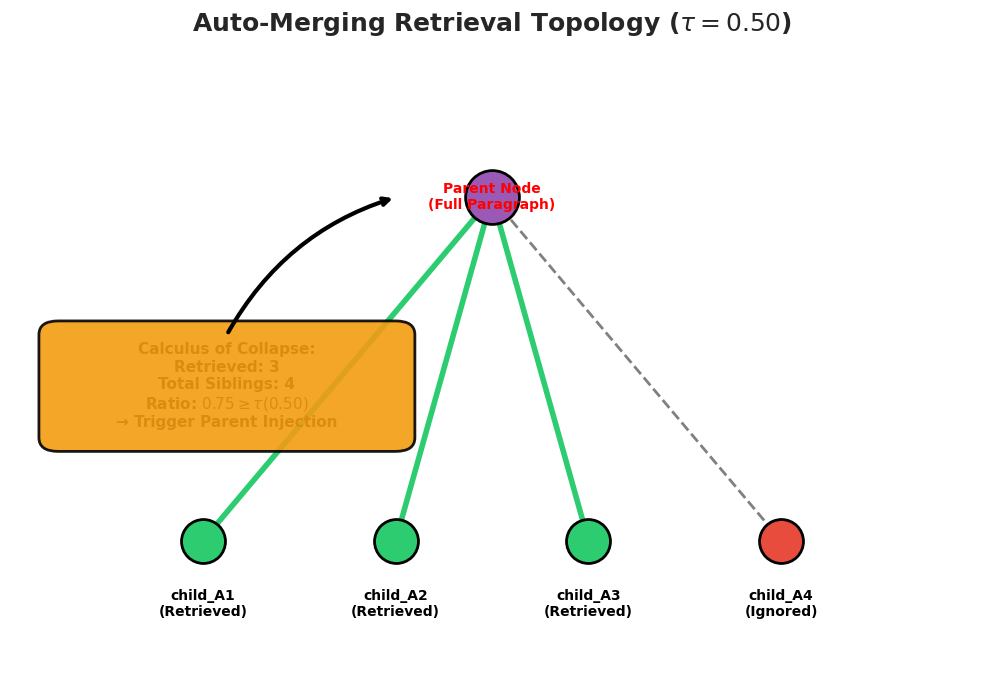

In [4]:
# Visualizing the Auto-Merging Graph Physics
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Auto-Merging Retrieval Topology ($\\tau = 0.50$)", fontsize=18, fontweight='bold')

ax.axis('off')

# Root Node (Parent)
parent_x, parent_y = 5, 8
ax.scatter(parent_x, parent_y, s=1500, color='#9b59b6', edgecolors='black', linewidth=2, zorder=3)
ax.text(parent_x, parent_y, "Parent Node\n(Full Paragraph)", color='red', fontweight='bold', ha='center', va='center', fontsize=10)

# Child Nodes
children_x = [2, 4, 6, 8]
children_y = [3, 3, 3, 3]
child_labels = ["child_A1\n(Retrieved)", "child_A2\n(Retrieved)", "child_A3\n(Retrieved)", "child_A4\n(Ignored)"]
colors = ['#2ecc71', '#2ecc71', '#2ecc71', '#e74c3c']

# Draw Edges (with varying thickness based on retrieval activation)
for i, (cx, cy) in enumerate(zip(children_x, children_y)):
    if colors[i] == '#2ecc71': # Active path
        ax.plot([parent_x, cx], [parent_y, cy], color='#2ecc71', linewidth=4, zorder=1)
    else: # Inactive path
        ax.plot([parent_x, cx], [parent_y, cy], color='gray', linewidth=2, linestyle='--', zorder=1)

# Draw Child Nodes
for i, (cx, cy) in enumerate(zip(children_x, children_y)):
    ax.scatter(cx, cy, s=1000, color=colors[i], edgecolors='black', linewidth=2, zorder=3)
    ax.text(cx, cy - 0.7, child_labels[i], color='black', fontweight='bold', ha='center', va='top', fontsize=10)

# The Mathematical Threshold Box
threshold_box = patches.FancyBboxPatch((0.5, 4.5), 3.5, 1.5, boxstyle="round,pad=0.2", 
                                       linewidth=2, edgecolor='black', facecolor='#f39c12', alpha=0.9, zorder=4)
ax.add_patch(threshold_box)

math_text = "Calculus of Collapse:\n"
math_text += "Retrieved: 3\nTotal Siblings: 4\nRatio: $0.75 \\geq \\tau (0.50)$\n"
math_text += "→ Trigger Parent Injection"
ax.text(2.25, 5.25, math_text, color='black', fontweight='bold', ha='center', va='center', fontsize=11)

# Collapse Arrow
ax.annotate("", xy=(parent_x - 1, parent_y), xytext=(2.25, 6.0), 
            arrowprops=dict(arrowstyle="->", color="black", lw=3, connectionstyle="arc3,rad=-0.2"), zorder=5)

plt.xlim(0, 10)
plt.ylim(1, 10)
plt.tight_layout()
plt.show()


## Real-World Use Case or Analogy:

Think of Auto-Merging Trees like **Searching an Encyclopedia**:

* **Standard Chunking**: You want to know about the Apollo 11 moon landing. Standard chunking rips the encyclopedia into millions of individual sentences. You search for "Apollo 11". The librarian hands you a single strip of paper that says: *"Armstrong stepped onto the surface at 02:56 UTC."* You ask, *"Who is Armstrong? What surface? What date?"* The system failed because it lacks context.
* **Parent-Child Retrieval**: You search for "Apollo 11". The librarian checks an index card (The Child Vector). The index card is highly specific, pointing exactly to Volume A, Page 42, Paragraph 3. Instead of giving you the tiny index card, the librarian hands you the entire **Paragraph** (The Parent Chunk). You read it and perfectly understand the context.
* **Auto-Merging Collapse**: You submit a massive research query about "The entire Space Race timeline". The librarian checks the index cards. They realize that 18 different index cards are all pointing to the same **Chapter** in Volume A. Instead of giving you 18 duplicate photocopies of the same paragraphs, the librarian collapses the request and simply drops the entire **Textbook Chapter** on your desk. Efficient, comprehensive, and perfectly contextual.